# Bayesian posterior tutorial for Figure 4 synthetic fitting

맞습니다. 이 프로젝트에서는 이미 **Bayesian posterior sampling**도 넣어뒀습니다.

이 노트북은 Figure 4 synthetic fitting 결과를 바탕으로:

1. 왜 posterior가 필요한지
2. posterior를 어떤 수식으로 정의하는지
3. `emcee`로 어떻게 샘플링하는지
4. posterior predictive를 어떻게 해석하는지

를 처음 보는 사람이 따라가기 쉽게 정리합니다.


## 1. 왜 point estimate만으로는 부족한가

최적화는 하나의 대표해 $\hat{\theta}$ 를 줍니다.

$$
\hat{\theta} = \arg\min_{\theta \in \Theta} J(\theta)
$$

하지만 Figure 4 스타일 문제에서는 $T + D$만 관측되기 때문에, `psi`, `omega`, `kappa`가 서로 어느 정도 보상될 수 있습니다.

즉, **한 점 추정값만 보면 그 해가 얼마나 불확실한지 알 수 없습니다.**

그래서 posterior 분포

$$
p(\theta \mid \text{data})
$$

를 보고,

- 어떤 파라미터가 넓게 흔들리는지
- 어떤 파라미터가 잘 식별되는지
- 그 불확실성이 예측 곡선에 얼마나 번지는지

를 같이 봐야 합니다.


## 2. posterior를 어떻게 정의하는가

현재 synthetic study에서는 residual vector를

$$
r(\theta)
$$

라고 두고, log-probability를

$$
\log p(\theta \mid \text{data}) = C - \frac{1}{2}\|r(\theta)\|_2^2
$$

꼴로 둡니다. 여기서 $C$는 상수입니다.

현재 residual은 두 부분으로 이루어집니다.

### 2.1 데이터 residual

$$
r_i(\theta) = \log(V_i^{pred}(\theta)+\epsilon) - \log(V_i^{obs}+\epsilon)
$$

### 2.2 weak prior residual

$$
r_j^{prior}(\theta) = \frac{\log(\theta_j)-\log(\theta_{j,base})}{\sigma_{prior}}
$$

따라서 전체 residual은

$$
r(\theta) = \begin{bmatrix}
r_{data}(\theta) \\
r_{prior}(\theta)
\end{bmatrix}
$$

이고, posterior는 사실상

$$
p(\theta \mid \text{data}) \propto \exp\left(-\frac{1}{2}\|r(\theta)\|_2^2\right)
$$

로 놓고 샘플링합니다.


## 3. 샘플링 방법

여기서는 `emcee`의 ensemble MCMC를 씁니다.

초기점은 최적화 해 근처에서 시작합니다.

$$
\theta^{(0)}_w \approx \hat{\theta} \times \exp(\eta_w), \quad \eta_w \sim \mathcal{N}(0, \sigma_{init}^2)
$$

그다음 여러 walker가 posterior를 따라 움직이며 샘플을 만듭니다.

이 노트북에서는 이미 구현된 함수를 그대로 사용합니다.


In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if not (repo_root / 'radiology_modeling').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print('repo_root =', repo_root)


repo_root = /drive2/2026/Radiology


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from radiology_modeling.fit import DEFAULT_FIT_SPECS, fit_synthetic_dataset, generate_synthetic_dataset
from radiology_modeling.model import ModelParameters
from radiology_modeling.synthetic_study import sample_posterior, summarize_posterior

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 4)


## 4. synthetic dataset과 point estimate 준비

먼저 Figure 4와 같은 two-arm synthetic dataset을 만들고, 최적화 기반 point estimate를 구합니다.


In [3]:
true_params = ModelParameters(
    rho=0.5,
    psi=300.0,
    omega=0.135,
    k=1.1,
    gamma=0.0,
    initial_volume=0.03,
    treatment_day=10,
    dose_gy=10.0,
)
base_params = ModelParameters()

dataset = generate_synthetic_dataset(
    true_params,
    coverages=(0.5, 1.0),
    noise_sigma=0.08,
    seed=7,
)
fit_result = fit_synthetic_dataset(
    dataset,
    base_params=base_params,
    fit_specs=DEFAULT_FIT_SPECS,
    seed=11,
)

pd.DataFrame([
    {
        'parameter': spec.name,
        'true': fit_result.true_values[spec.name],
        'fitted': fit_result.fitted_values[spec.name],
        'rel_error_pct': 100.0 * (fit_result.fitted_values[spec.name] - fit_result.true_values[spec.name]) / fit_result.true_values[spec.name],
    }
    for spec in fit_result.parameter_specs
])


,parameter,true,fitted,rel_error_pct
0,psi,300.000,305.2886,1.7629
1,omega,0.135,0.1372,1.5928
2,k,1.100,1.1045,0.4105
3,initial_volume,0.030,0.0300,-0.0513


## 5. posterior sampling 실행

이제 point estimate 근처에서 posterior를 샘플링합니다.

기본 설정은 다음과 같습니다.

- walkers: 24
- steps: 900
- burn-in: 300
- thin: 4


In [4]:
samples, sampler = sample_posterior(
    dataset,
    fit_result,
    base_params=base_params,
    n_walkers=24,
    n_steps=900,
    burn_in=300,
    thin=4,
    seed=17,
)

posterior_df = summarize_posterior(samples, DEFAULT_FIT_SPECS)
posterior_df


,parameter,mean,std,q05,q50,q95
0,psi,341.4386,117.5382,184.3362,322.7409,565.2190
1,omega,0.1737,0.0424,0.1130,0.1690,0.2530
2,k,1.2074,0.3735,0.6897,1.1652,1.8921
3,initial_volume,0.0356,0.0091,0.0227,0.0343,0.0521


In [5]:
print('samples shape =', samples.shape)
print('mean acceptance fraction =', float(np.mean(sampler.acceptance_fraction)))
try:
    print('autocorr time =', sampler.get_autocorr_time(tol=0))
except Exception as exc:
    print('autocorr time unavailable:', exc)


samples shape = (3600, 4)
mean acceptance fraction = 0.5642592592592592
autocorr time = [30.8580261  39.52588424 34.03768569 39.24424362]


## 6. trace plot과 marginal posterior

trace plot은 체인이 안정적으로 섞이는지 보는 데 쓰고, marginal posterior는 각 파라미터의 불확실성을 보여줍니다.


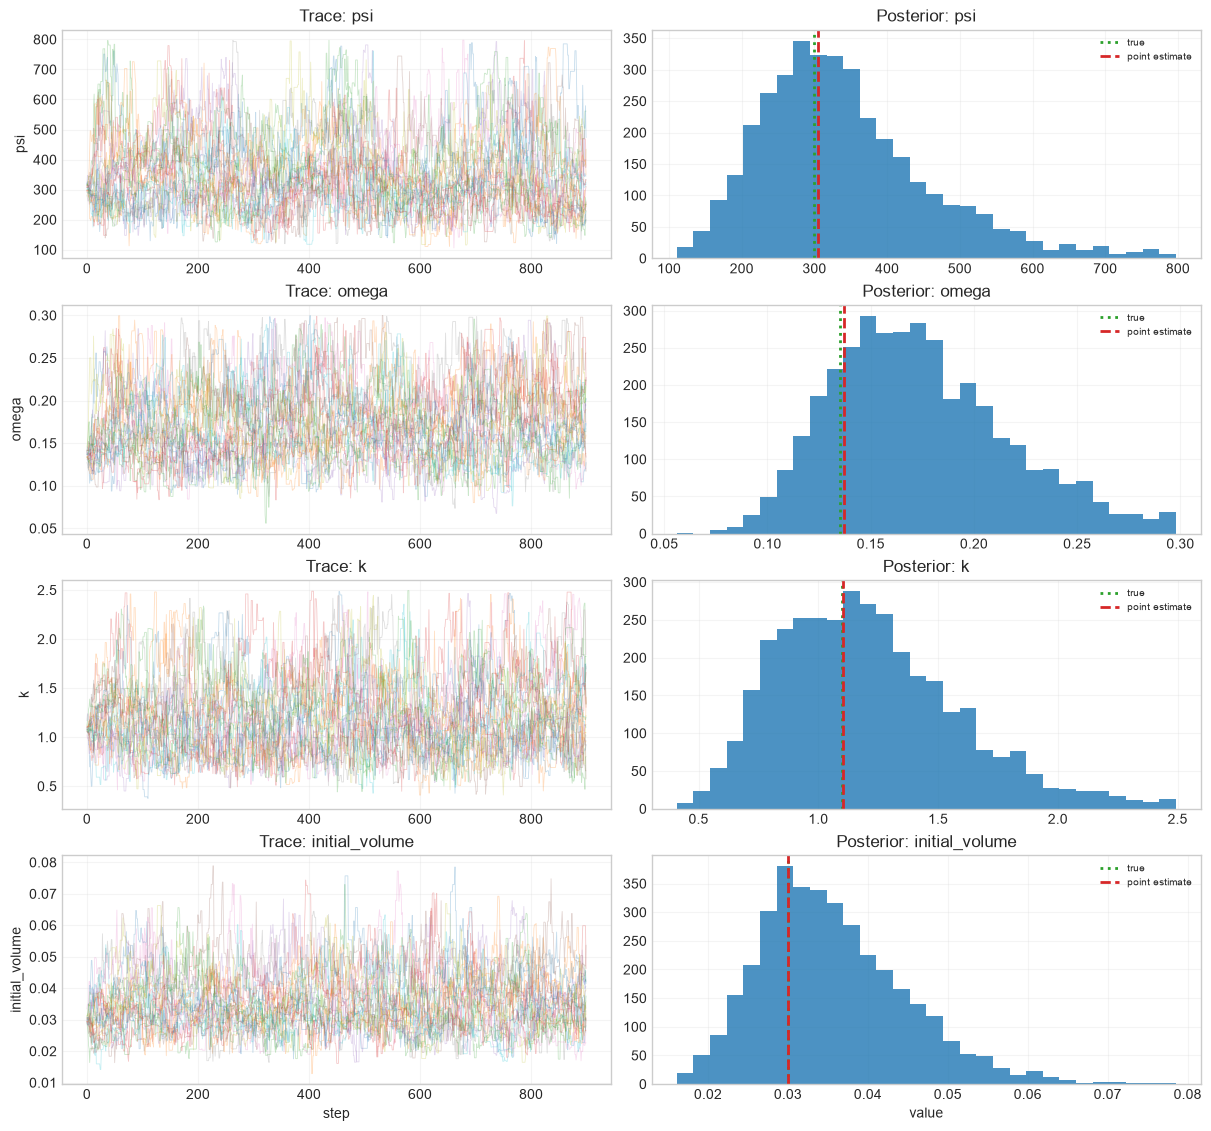

In [6]:
chain = sampler.get_chain()
ndim = len(DEFAULT_FIT_SPECS)
fig, axes = plt.subplots(ndim, 2, figsize=(12, 2.8 * ndim), constrained_layout=True)
for i, spec in enumerate(DEFAULT_FIT_SPECS):
    axes[i, 0].plot(chain[:, :, i], alpha=0.25, linewidth=0.6)
    axes[i, 0].set_title(f'Trace: {spec.name}')
    axes[i, 0].set_ylabel(spec.name)
    axes[i, 0].grid(True, alpha=0.2)

    axes[i, 1].hist(samples[:, i], bins=30, color='tab:blue', alpha=0.8)
    axes[i, 1].axvline(fit_result.true_values[spec.name], color='tab:green', linestyle=':', linewidth=2, label='true')
    axes[i, 1].axvline(fit_result.fitted_values[spec.name], color='tab:red', linestyle='--', linewidth=2, label='point estimate')
    axes[i, 1].set_title(f'Posterior: {spec.name}')
    axes[i, 1].grid(True, alpha=0.2)
    axes[i, 1].legend(fontsize=7)
axes[-1, 0].set_xlabel('step')
axes[-1, 1].set_xlabel('value')
plt.show()


## 7. posterior predictive

posterior sample을 여러 개 뽑아 각각 forward simulation을 돌리면, **파라미터 불확실성이 예측 곡선 불확실성으로 어떻게 번지는지** 볼 수 있습니다.


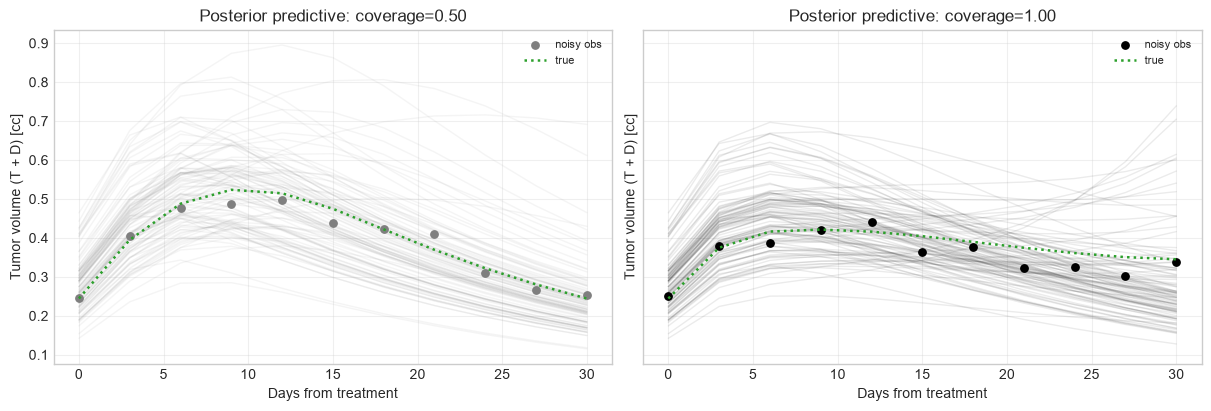

In [7]:
from radiology_modeling.fit import _vector_to_params
from radiology_modeling.model import simulate_experiment

rng = np.random.default_rng(23)
draw_indices = rng.choice(samples.shape[0], size=min(100, samples.shape[0]), replace=False)
fig, axes = plt.subplots(1, len(dataset.series), figsize=(12, 4), constrained_layout=True, sharey=True)
if len(dataset.series) == 1:
    axes = [axes]
for axis, series in zip(axes, dataset.series, strict=True):
    color = 'tab:gray' if np.isclose(series.coverage, 0.5) else 'black'
    for draw_index in draw_indices:
        params = _vector_to_params(base_params, DEFAULT_FIT_SPECS, samples[draw_index])
        prediction = simulate_experiment(params, coverage=series.coverage, num_days=181, n_voxels=100)
        axis.plot(series.relative_days, prediction.total_volume[series.absolute_days], color=color, alpha=0.08, linewidth=1)
    axis.scatter(series.relative_days, series.observed_volume, color=color, s=28, label='noisy obs')
    axis.plot(series.relative_days, series.clean_volume, color='tab:green', linestyle=':', linewidth=1.8, label='true')
    axis.set_title(f'Posterior predictive: coverage={series.coverage:.2f}')
    axis.set_xlabel('Days from treatment')
    axis.set_ylabel('Tumor volume (T + D) [cc]')
    axis.grid(True, alpha=0.3)
    axis.legend(fontsize=8)
plt.show()


## 8. posterior 요약 해석

이 단계에서 보통 확인할 포인트는 다음과 같습니다.

- `initial_volume`은 posterior가 상대적으로 더 좁습니다.
- `psi`, `omega`, `kappa`는 더 넓게 퍼집니다.
- 즉 point estimate는 잘 맞아도, 면역 관련 파라미터는 불확실성이 꽤 남아 있습니다.

이건 곧:

1. Figure 4 스타일의 `T + D` 데이터만으로는 식별성에 한계가 있고
2. 추가 immune readout이나
3. Bayesian uncertainty quantification

이 실제 데이터 단계에서 필요하다는 뜻입니다.


## 9. 실전 해석

이 posterior는 단순히 숫자 범위를 보는 용도만이 아닙니다.

실제로는 여기서 더 나아가:

- control probability
- regrowth delay
- partial vs full regimen ranking
- critical volume crossing time

같은 **derived endpoint의 posterior**를 계산하는 쪽이 더 중요합니다.

즉 Bayesian 단계의 진짜 목적은 파라미터 자체보다 **예측 불확실성 전파**에 있습니다.


## 10. 요약

이 노트북에서 한 일은 다음과 같습니다.

1. Figure 4 synthetic noisy data 생성
2. point estimate 계산
3. `emcee`로 posterior sampling
4. trace / marginal posterior 확인
5. posterior predictive 확인

즉 이 프로젝트에서 말한 **Bayesian posterior 어쩌구**는 실제로 이미 구현되어 있었고, 이제 notebook으로도 따라갈 수 있게 정리된 상태입니다.
